<a href="https://colab.research.google.com/github/MHMDHL/linux-monitor/blob/main/T2520_Assignment_Part_III_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the template for the students to start working on the Assignment Part III

Import the libraries

In [1]:
import pandas as pd
from pandas import read_csv
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Load the dataset

In [2]:
df = read_csv("https://raw.githubusercontent.com/wooihaw/datasets/main/steel_faults.csv")
df.head()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Fault
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,Pastry


What is the dimension of this dataset?

In [3]:
df.shape

(1941, 28)

In [4]:
df.describe()

,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,...,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,...,0.033361,0.610529,0.813472,0.575734,2.492388,1.335686,1.403271,0.083288,-0.131305,0.585420
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,...,0.058961,0.243277,0.234274,0.482352,0.788930,0.481612,0.454345,0.500868,0.148767,0.339452
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,...,0.001500,0.014400,0.048400,0.000000,0.301000,0.301000,0.000000,-0.991000,-0.998900,0.119000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,...,0.006600,0.411800,0.596800,0.000000,1.924300,1.000000,1.079200,-0.333300,-0.195000,0.248200
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,...,0.010100,0.636400,0.947400,1.000000,2.240600,1.176100,1.322200,0.095200,-0.133000,0.506300
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,...,0.023500,0.800000,1.000000,1.000000,2.914900,1.518500,1.732400,0.511600,-0.066600,0.999800
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,...,0.875900,1.000000,1.000000,1.000000,5.183700,3.074100,4.258700,0.991700,0.642100,1.000000


How many types of fault?

In [5]:
df['Fault'].nunique()

7

Check for NaN

In [6]:
df.isna().sum()

,0
X_Minimum,0
X_Maximum,0
Y_Minimum,0
Y_Maximum,0
Pixels_Areas,0
X_Perimeter,0
Y_Perimeter,0
Sum_of_Luminosity,0
Minimum_of_Luminosity,0
Maximum_of_Luminosity,0


Use X and y to store the features and label

In [7]:
X = df.drop('Fault', axis=1)
y = df['Fault']

**Dimensionality Reduction**  
Reduce the dimensionality to only 5 features using PCA

In [8]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

Which features are the most important?

In [9]:
import numpy as np
import pandas as pd

# Extract the absolute weights from the first principal component
component_weights = np.abs(pca.components_[0])

# Match the weights to the original column names and sort them
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': component_weights
}).sort_values(by='Importance', ascending=False)

print(feature_importance.head())

             Feature  Importance
3          Y_Maximum    0.707108
2          Y_Minimum    0.707104
7  Sum_of_Luminosity    0.001583
4       Pixels_Areas    0.000037
1          X_Maximum    0.000010


From here, we notice that '`Y_Maximum`' is the most important feature, followed by '`Sum_of_Luminosity`'.

Get the index of the maximum value in each column (principal component)

In [10]:
# Find the index of the maximum absolute value across the columns (axis=1) for each component
max_indices = np.argmax(np.abs(pca.components_), axis=1)

# Map the indices back to the original column names
most_important_features = [X.columns[i] for i in max_indices]
print("Most important feature for each of the 5 principal components:")
print(most_important_features)

Most important feature for each of the 5 principal components:
['Y_Maximum', 'Sum_of_Luminosity', 'Pixels_Areas', 'X_Minimum', 'Length_of_Conveyer']


**k-Means Clustering**

In [11]:
from sklearn.cluster import KMeans

# Isolate the dataset to only the two most significant features
X_significant = X[['Y_Maximum', 'Sum_of_Luminosity']]

# Initialize k-Means with 7 clusters and a fixed random state for reproducibility
kmeans = KMeans(n_clusters=7, random_state=42)

# Fit the model and generate cluster labels for each data point
cluster_labels = kmeans.fit_predict(X_significant)

What is the Silhouette Coefficient?

In [12]:
from sklearn.metrics import silhouette_score

# Calculate the silhouette score using the significant features and their assigned clusters
score = silhouette_score(X_significant, cluster_labels)
print(f"Silhouette Coefficient: {score:.4f}")

Silhouette Coefficient: 0.5596


Before and after clustering

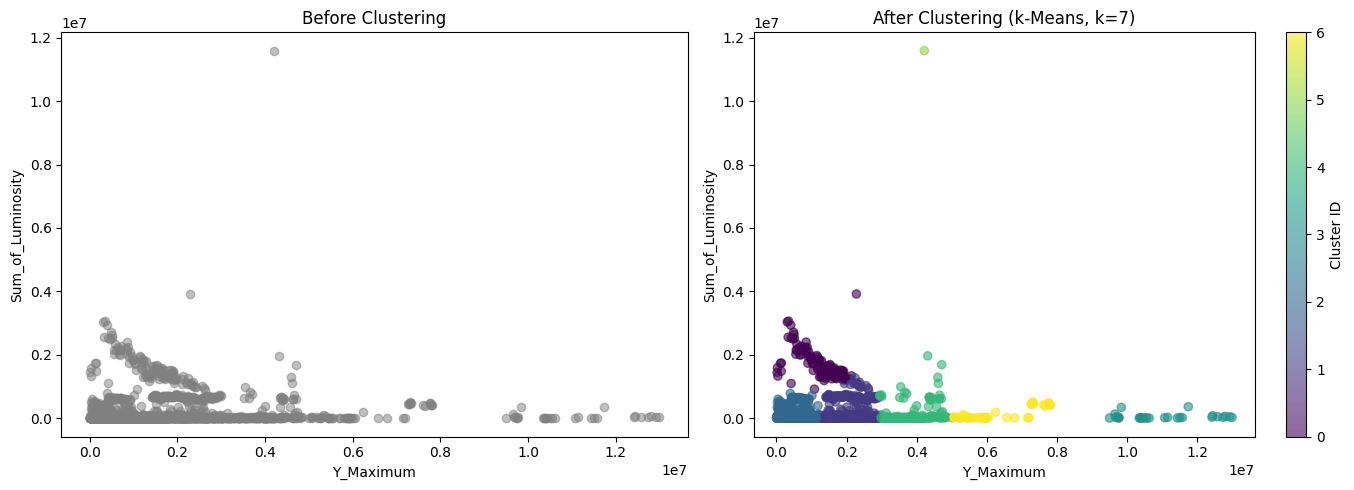

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Before clustering (all data points are the same color)
ax1.scatter(X_significant['Y_Maximum'], X_significant['Sum_of_Luminosity'], alpha=0.5, color='gray')
ax1.set_title("Before Clustering")
ax1.set_xlabel("Y_Maximum")
ax1.set_ylabel("Sum_of_Luminosity")

# Plot 2: After clustering (data points are colored by their cluster label)
scatter = ax2.scatter(X_significant['Y_Maximum'], X_significant['Sum_of_Luminosity'],
                      c=cluster_labels, cmap='viridis', alpha=0.6)
ax2.set_title("After Clustering (k-Means, k=7)")
ax2.set_xlabel("Y_Maximum")
ax2.set_ylabel("Sum_of_Luminosity")
plt.colorbar(scatter, ax=ax2, label='Cluster ID')

plt.tight_layout()
plt.show()